PCOS Dataset

Este dataset proviene de (https://www.kaggle.com/datasets/cm037divya/pcos-dataset/data). Contiene 2000 filas con 44 columnas.

Los nombres de las columnas son:

'Sl. No', 'Patient File No.', 'PCOS (Y/N)', 'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI', 'Blood Group', various hormonal levels like 'FSH(mIU/mL)', 'LH(mIU/mL)', 'TSH (mIU/L)', 'AMH(ng/mL)', lifestyle factors like 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', and measurements like 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Endometrium (mm)'

Este dataset fue reportado por el usuario: cm037divya, no contiene informacion de procedencia dentro de la descripcion del dataset pero si se muestra una especificacion para investigacion medica end donde se describe que la informacion es util para el estudio de prevalencia y caracteristicas del Sindrome de Ovario Poliquistico (PCOS en ingles). Tambien se indica que puede ser util para construir un modelo predictivo para PCOS basado en sintomas, nivel hormonal y factores de estilo de vida.

El dataset se compone de 2000 instancias las cuales estan divididas en 44 columnas con etiquetas para cada una.



Lo primero que haremos es importar las librerias de python para poder manipular el dataset. En las primeras 2 lineas esta la importacion de pandas y matplot lib, estas dos librerias nos permitiran manipular el archivo .csv, podremos abrirlo e imprimir el contedino de esta. Mathplotlib nos permitira utilizar herramientas graficas para la interpretacion de estos datos.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

filename = "PCOS_extended_dataset.csv"
dataset_path = None
## Esta parte la tuve que resolver con IA, mi problema fue que JNTBK no llegaba al archivo con el path "../Data/PCOS_extended_dataset.csv"
for folder in [Path.cwd(), *Path.cwd().parents]:
    candidates = [
        folder / filename,
        folder / "Datos" / filename,
    ]
    for candidate in candidates:
        if candidate.is_file():
            dataset_path = candidate
            break
    if dataset_path:
        break

if dataset_path is None:
    raise FileNotFoundError(
        f"No se encontró {filename}. Verifica que esté dentro de una carpeta 'Datos'."
    )
## Hasta aqui resolvio.

df = pd.read_csv(dataset_path)
df.columns = df.columns.str.strip()

print(f"Archivo cargado desde: {dataset_path}")

df  


Archivo cargado desde: c:\Users\capim\OneDrive\Escritorio\ICD-2026\Datos\PCOS_extended_dataset.csv


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,193,193,0,30,69.979147,167.708055,23.185569,12,72,22,...,1,0.0,1,105.483401,76.096379,2,4,10.0,13.0,6.176029
1,360,360,0,36,63.711688,154.055877,25.441392,13,70,18,...,1,0.0,1,115.883740,79.117243,2,3,13.0,11.0,6.824718
2,10,10,0,36,51.848631,149.059804,23.928264,15,80,20,...,0,0.0,0,112.219711,80.919417,1,1,14.0,17.0,2.568691
3,278,278,1,29,66.893988,148.628036,27.894935,15,72,18,...,0,0.0,1,104.619624,69.902681,1,1,12.0,14.0,9.962732
4,71,71,0,33,52.536198,150.767409,23.079564,13,72,18,...,0,0.0,0,99.175454,70.330461,5,2,11.5,4.7,6.655190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,87,87,0,31,66.948922,155.976858,26.662263,15,74,18,...,0,0.0,0,120.323951,83.738573,8,10,15.0,13.0,9.816150
1996,508,508,0,37,64.592788,151.979792,27.681715,11,74,20,...,0,1.0,0,109.738395,76.083303,6,6,19.0,19.0,7.930382
1997,166,166,0,32,47.750129,148.596447,20.041406,11,73,26,...,1,1.0,0,109.570220,61.778231,5,5,14.0,13.0,6.832224
1998,266,266,0,40,31.869660,152.589988,13.793101,15,72,20,...,0,1.0,1,119.456176,79.410616,6,5,18.0,17.0,7.636086


A continuacion utilizamos la funcion df.shape para obtener el tamaño del dataset. Al correr el codigo nos damos cuenta que tenemos un dataset de 2000 filas con 44 columnas, los indices de cada columna fueron discutidos en la primer parte de este documento.

In [19]:
df.shape

(2000, 44)

Seguimos con la funcion df.loc[], esta funcion nos permite imprimir para el primer sujeto (objeto o instance) los datos registrados con sus correspondientes columnas para observar la composicion del df.

In [20]:
df.loc[1]

Sl. No                           360
Patient File No.                 360
PCOS (Y/N)                         0
Age (yrs)                         36
Weight (Kg)                63.711688
Height(Cm)                154.055877
BMI                        25.441392
Blood Group                       13
Pulse rate(bpm)                   70
RR (breaths/min)                  18
Hb(g/dl)                        10.5
Cycle(R/I)                         2
Cycle length(days)                 6
Marraige Status (Yrs)           12.0
Pregnant(Y/N)                      1
No. of abortions                   0
I   beta-HCG(mIU/mL)           418.9
II    beta-HCG(mIU/mL)         418.9
FSH(mIU/mL)                     2.85
LH(mIU/mL)                      1.71
FSH/LH                          1.67
Hip(inch)                         38
Waist(inch)                       35
Waist:Hip Ratio                 0.92
TSH (mIU/L)                     1.54
AMH(ng/mL)                      3.09
PRL(ng/mL)                     26.09
V

La fucion df["PCOS (Y/N)"] fue utilizada debido a que esta coluna nos indica una caracteriztica determinante para el analisis. Esta columna contiene en binario la respuesta a si el objeto o instacia fue positivo o negativo para el sindrome de ovario poliquistico.

In [21]:
df["PCOS (Y/N)"]

0       0
1       0
2       0
3       1
4       0
       ..
1995    0
1996    0
1997    0
1998    0
1999    1
Name: PCOS (Y/N), Length: 2000, dtype: int64

df.dtypes nos permite ver el tipo de dato para cada columna.

In [22]:
df.dtypes

Sl. No                      int64
Patient File No.            int64
PCOS (Y/N)                  int64
Age (yrs)                   int64
Weight (Kg)               float64
Height(Cm)                float64
BMI                       float64
Blood Group                 int64
Pulse rate(bpm)             int64
RR (breaths/min)            int64
Hb(g/dl)                  float64
Cycle(R/I)                  int64
Cycle length(days)          int64
Marraige Status (Yrs)     float64
Pregnant(Y/N)               int64
No. of abortions            int64
I   beta-HCG(mIU/mL)      float64
II    beta-HCG(mIU/mL)        str
FSH(mIU/mL)               float64
LH(mIU/mL)                float64
FSH/LH                    float64
Hip(inch)                   int64
Waist(inch)                 int64
Waist:Hip Ratio           float64
TSH (mIU/L)               float64
AMH(ng/mL)                    str
PRL(ng/mL)                float64
Vit D3 (ng/mL)            float64
PRG(ng/mL)                float64
RBS(mg/dl)    

Continuando con df.info() nos permite ver un resumen consiso y general de la estructura de un dataframe.

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  2000 non-null   int64  
 1   Patient File No.        2000 non-null   int64  
 2   PCOS (Y/N)              2000 non-null   int64  
 3   Age (yrs)               2000 non-null   int64  
 4   Weight (Kg)             2000 non-null   float64
 5   Height(Cm)              2000 non-null   float64
 6   BMI                     2000 non-null   float64
 7   Blood Group             2000 non-null   int64  
 8   Pulse rate(bpm)         2000 non-null   int64  
 9   RR (breaths/min)        2000 non-null   int64  
 10  Hb(g/dl)                2000 non-null   float64
 11  Cycle(R/I)              2000 non-null   int64  
 12  Cycle length(days)      2000 non-null   int64  
 13  Marraige Status (Yrs)   1997 non-null   float64
 14  Pregnant(Y/N)           2000 non-null   int64  
 15

In [24]:
df.describe(
    include=["object", "bool" ]
)


C:\Users\capim\AppData\Local\Temp\ipykernel_14476\285741719.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(


,II beta-HCG(mIU/mL),AMH(ng/mL)
count,2000,2000
unique,200,298
top,1.99,1.2
freq,1136,28


## Calidad de datos:

En esta sección se evalúa la integridad y consistencia del dataset antes de proceder con cualquier análisis estadístico, ya que la presencia de valores faltantes, duplicados o inconsistentes puede sesgar los resultados o llevar a conclusiones erróneas.

Valores faltantes: solo 2 de las 44 columnas presentan datos faltantes, ambas con un porcentaje mínimo (0.15%, equivalente a 3 filas cada una). Entre las variables hormonales mencionadas (AMH(ng/mL), II beta-HCG(mIU/mL), FSH(mIU/mL)), únicamente AMH(ng/mL) presenta valores faltantes — los otros dos no tienen ningún nulo. En cuanto al patrón, los 3 casos nulos de Marraige Status (Yrs) corresponden todos a pacientes sin diagnóstico de PCOS (PCOS=0); sin embargo, dado el tamaño tan pequeño de la muestra (solo 3 casos), no hay evidencia suficiente para concluir un sesgo sistemático de recolección — parece más bien una ausencia aleatoria y puntual.

Duplicados: se verifica si existen registros repetidos a partir de Sl. No y Patient File No., dado que cada fila debería representar una paciente única. La presencia de duplicados podría inflar artificialmente el tamaño muestral y distorsionar las distribuciones.

In [25]:
duplicados_totales = df.duplicated().sum()
print(f"Filas duplicadas idénticas en el dataset: {duplicados_totales}")
print("----------------------------------------------------------------")

porcentaje_nulos = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(porcentaje_nulos)

df = df.drop_duplicates()
df.duplicated().sum()
print("----------------------------------------------------------------")

Filas duplicadas idénticas en el dataset: 0
----------------------------------------------------------------
Marraige Status (Yrs)     0.15
Sl. No                    0.00
PCOS (Y/N)                0.00
Patient File No.          0.00
Weight (Kg)               0.00
Height(Cm)                0.00
BMI                       0.00
Blood Group               0.00
Pulse rate(bpm)           0.00
RR (breaths/min)          0.00
Hb(g/dl)                  0.00
Age (yrs)                 0.00
Cycle(R/I)                0.00
Cycle length(days)        0.00
Pregnant(Y/N)             0.00
No. of abortions          0.00
I   beta-HCG(mIU/mL)      0.00
II    beta-HCG(mIU/mL)    0.00
FSH(mIU/mL)               0.00
LH(mIU/mL)                0.00
FSH/LH                    0.00
Hip(inch)                 0.00
Waist(inch)               0.00
Waist:Hip Ratio           0.00
TSH (mIU/L)               0.00
AMH(ng/mL)                0.00
PRL(ng/mL)                0.00
Vit D3 (ng/mL)            0.00
PRG(ng/mL)             

## Análisis univariado

En esta sección se examina la distribución individual de los atributos numéricos clínicamente relevantes, con el objetivo de comprender su comportamiento general, detectar asimetrías, posibles valores atípicos y evaluar si sus escalas y rangos son consistentes con lo esperado fisiológicamente, antes de explorar relaciones entre variables.

El pie chart que se muestra a continuacion nos habla de la distribucion entre pacientes con PCOS diagnosticado y no diagnosticado. De las 2000 instancias que contiene este dataset tenemoms que el 69% son casos sin PCOS y el 30.4% es de aquellos que si presentan PCOS.

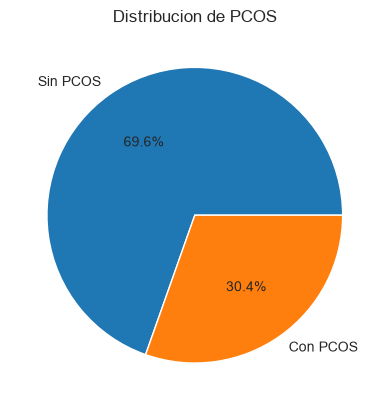

In [26]:
df["PCOS (Y/N)"].value_counts().rename({
        0: "Sin PCOS",
        1: "Con PCOS"
    }).plot(kind="pie",autopct="%1.1f%%",ylabel="")
plt.title("Distribucion de PCOS")
plt.show()


## Histograma para distribucion de edad

En el grafico podemos observar una distribucion unimodal, donde se concentra la mayoria de observaciones entre 25 a 35 años. Esto corresponde a la edad de diagnostico tipica para mujeres en edad reproductiva.

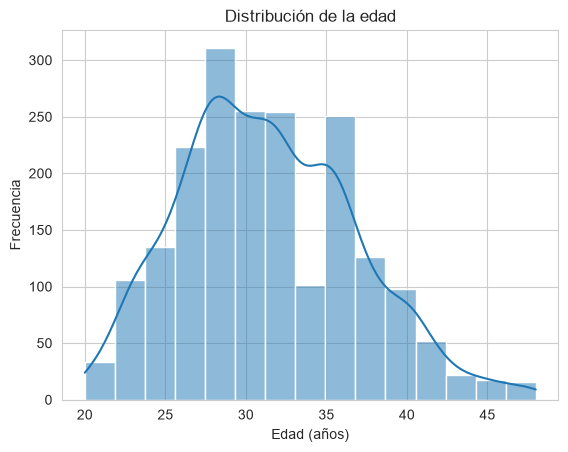

In [27]:
sns.histplot(data=df, x="Age (yrs)", kde=True, bins=15)

plt.title("Distribución de la edad")
plt.xlabel("Edad (años)")
plt.ylabel("Frecuencia")
plt.show()

## Scatter plot

Utilizaremos el scatter plot para observar la relacion entre altura y peso para obtener el BMI de los pacientes. El BMI esta realcionado con SOP, derivado de este, el paciente produce mas Androgenos (Testosterona) que a su vez favorece la acummulacion de grasa abdomminal (IMC alto) lo cual se relaciona con insulina alta que a su vez estimula a los ovarios a producir mas androgenos y genera una resistencia a la insulina.

In [28]:
scatter = sns.scatterplot(
    data=df,
    x="Height(Cm) ",
    y="Weight (Kg)",
    hue="BMI",
    palette="viridis",
    size="BMI",
    sizes=(20,100)
)

ValueError: Could not interpret value `Height(Cm) ` for `x`. An entry with this name does not appear in `data`.

Ahora analizaremos el ciclo menstrual, este forma parte de los indicadores de diagnostico, ya que los ciclos irregulares (muy cortos o muy largos) suelen asociarse con PCOS. Se espera observar una distribucion bimodal o con cola larga si coexisten paciente con ciclos regulares e irregulares.

El siguiente grafico nos mmuestra algo interesante, en donde podemos ver que para pacientes con periodo irregular tiene una mediana de 4 dias con valores atipicos de hasta 12 o 0 dias (Amenorrea), mientras que aquellas pacientes con periodos regulares tiene un aproximado de dias de sangrado de 5 con valores atipicos de 3-7 dias lo que corresponde con un periodo regular.

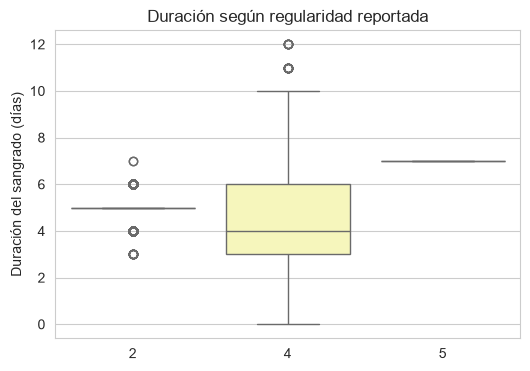

In [29]:
sns.set_style("whitegrid")

df["Cycle length(days)"] = pd.to_numeric(df["Cycle length(days)"], errors="coerce")

df_plot = df.dropna(subset=["Cycle(R/I)", "Cycle length(days)"])

plt.figure(figsize=(6, 4))
sns.boxplot(
    x="Cycle(R/I)",
    y="Cycle length(days)",
    data=df_plot,
    hue="Cycle(R/I)",
    palette="Set3",
    legend=False
)
plt.title("Duración según regularidad reportada")
plt.xlabel("")
plt.ylabel("Duración del sangrado (días)")
plt.show()

Ahora exploraremos la relacion de la hormona antimulleriana, esta es uno de los marcadores bioquimicos mas fuertes de PCOS, ya que refleja la reserva folicular ovarica, tipicamente elevada en estas pacientes.

El boxplot comparativo muestra una diferencia clara entre grupos: las pacientes con PCOS presentan una mediana de AMH aproximadamente el doble que las pacientes sin PCOS (~7 vs ~3 ng/mL), junto con una dispersión considerablemente mayor. Este patrón es consistente con la literatura clínica, que reporta AMH elevada como uno de los marcadores bioquímicos más fuertes asociados a PCOS, reflejando una mayor reserva folicular ovárica. Se observa además un valor atípico aislado cercano a 65 ng/mL en el grupo con PCOS, muy por encima del resto de la distribución, que debería verificarse como posible error de captura antes de continuar con análisis cuantitativos más sensibles a outliers.

             count  mean   std   min   25%  50%   75%   max
PCOS (Y/N)                                                 
0           1389.0  4.70  4.34  0.16  2.00  3.3   5.8  26.8
1            608.0  8.87  9.42  0.10  3.59  6.3  10.8  66.0


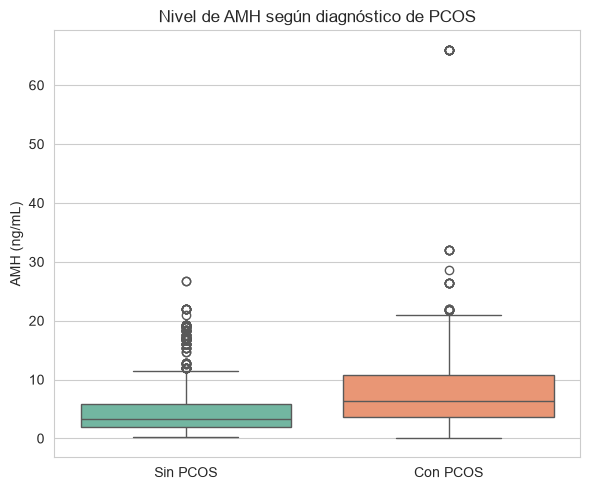

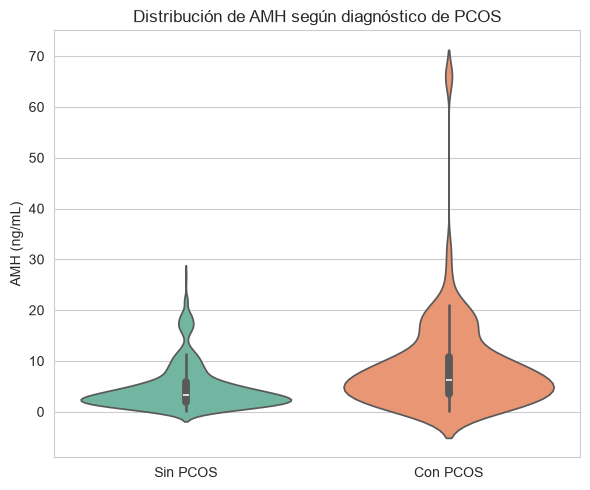

In [30]:
sns.set_style("whitegrid")

df = pd.read_csv(dataset_path)
df.columns = df.columns.str.strip()

df["AMH(ng/mL)"] = pd.to_numeric(df["AMH(ng/mL)"], errors="coerce")

print(df.groupby("PCOS (Y/N)")["AMH(ng/mL)"].describe().round(2))

df_plot = df.dropna(subset=["PCOS (Y/N)", "AMH(ng/mL)"])

plt.figure(figsize=(6, 5))
sns.boxplot(
    x="PCOS (Y/N)", y="AMH(ng/mL)", data=df_plot,
    hue="PCOS (Y/N)", palette="Set2", legend=False
)
plt.xticks([0, 1], ["Sin PCOS", "Con PCOS"])
plt.xlabel("")
plt.ylabel("AMH (ng/mL)")
plt.title("Nivel de AMH según diagnóstico de PCOS")
plt.tight_layout()
plt.savefig("amh_vs_pcos_boxplot.png", dpi=150)
plt.show()


plt.figure(figsize=(6, 5))
sns.violinplot(
    x="PCOS (Y/N)", y="AMH(ng/mL)", data=df_plot,
    hue="PCOS (Y/N)", palette="Set2", legend=False
)
plt.xticks([0, 1], ["Sin PCOS", "Con PCOS"])
plt.xlabel("")
plt.ylabel("AMH (ng/mL)")
plt.title("Distribución de AMH según diagnóstico de PCOS")
plt.tight_layout()
plt.savefig("amh_vs_pcos_violin.png", dpi=150)
plt.show()


# Analisis de razgos cualtitativos para las pacientes con PCOS y sin el

A continuacion se mostraran graficos de barras primero para razgos fisicos reportados para las pacientes con ovario poliquistico diagnosticado. Esto quiere decir que si presentan dentro de una evaluacion fisica el allazgo de un ovario poliquistico, lo cual puede presentar desajuste hormonal y derivar en sintomas fisicos como perdida de cabello, aumento de peso, crecimiento de bello, espinillas y oscurecimiento de piel (relacionado con resistencia a la insulina).

--------------------------------------------------
Separacion por objetivo, positivos para PCOS y negativos para PCOS:


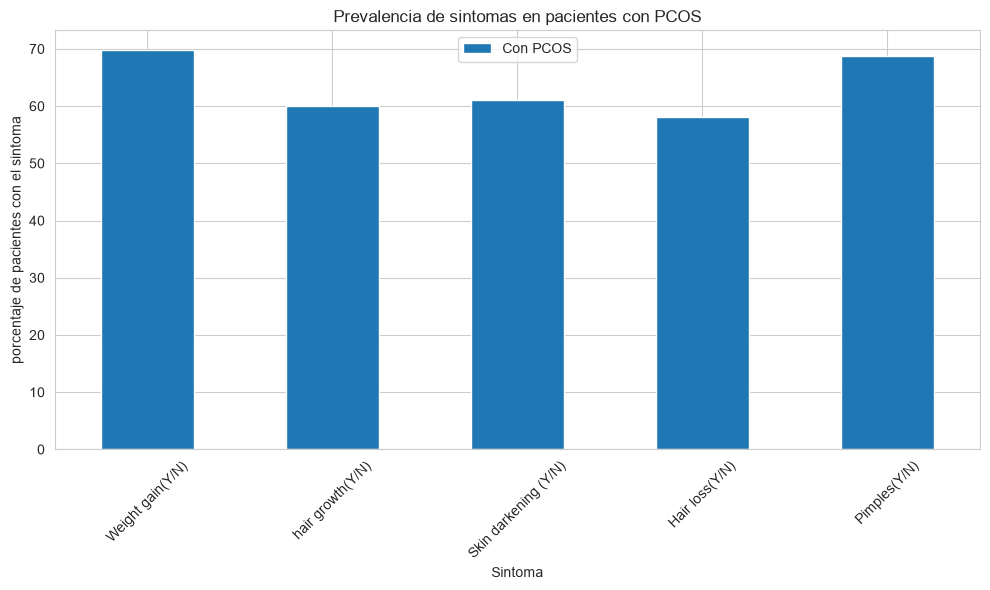

In [33]:
print("--------------------------------------------------")
print("Separacion por objetivo, positivos para PCOS y negativos para PCOS:")
df_0 = df[df["PCOS (Y/N)"] == 0]
df_1 = df[df["PCOS (Y/N)"] == 1]

df_1 = df_1[[
    "PCOS (Y/N)",
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)"
]]

df_0 = df_0[[
    "PCOS (Y/N)",
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)"
]]

sintomas = [
    #"PCOS (Y/N)",
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)"
]

# % de pacientes con cada sintoma, separado por positivo a PCOS 
proporciones = df_1.groupby("PCOS (Y/N)")[sintomas].mean() * 100
proporciones.T.plot(kind="bar", figsize=(10,6))
plt.ylabel("porcentaje de pacientes con el sintoma")
plt.xlabel("Sintoma")
plt.title("Prevalencia de sintomas en pacientes con PCOS")
plt.legend(["Con PCOS"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

--------------------------------------------------
Separacion por objetivo, positivos para PCOS y negativos para PCOS:
            Weight gain(Y/N)  hair growth(Y/N)  Skin darkening (Y/N)  \
PCOS (Y/N)                                                             
0                   24.20977         13.218391             15.014368   

            Hair loss(Y/N)  Pimples(Y/N)  
PCOS (Y/N)                                
0                38.362069     38.505747  


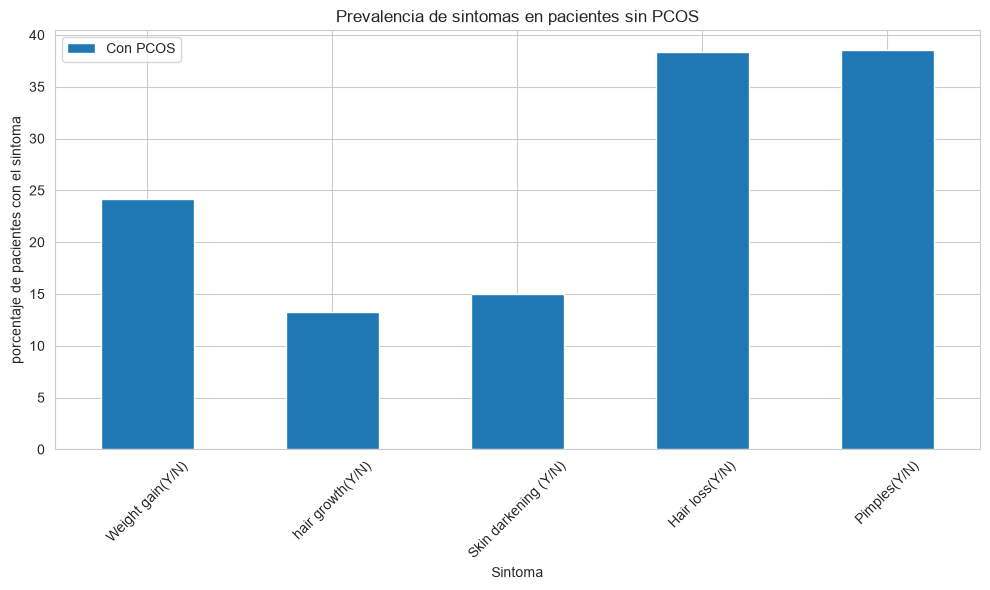

In [34]:
print("--------------------------------------------------")
print("Separacion por objetivo, positivos para PCOS y negativos para PCOS:")
df_0 = df[df["PCOS (Y/N)"] == 0]
df_1 = df[df["PCOS (Y/N)"] == 1]

df_1 = df_1[[
    "PCOS (Y/N)",
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)"
]]

df_0 = df_0[[
    "PCOS (Y/N)",
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)"
]]

sintomas = [
    #"PCOS (Y/N)",
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)"
]

# % de pacientes con cada sintoma, separado por negativo a PCOS 
proporciones = df_0.groupby("PCOS (Y/N)")[sintomas].mean() * 100
print(proporciones)
proporciones.T.plot(kind="bar", figsize=(10,6))
plt.ylabel("porcentaje de pacientes con el sintoma")
plt.xlabel("Sintoma")
plt.title("Prevalencia de sintomas en pacientes sin PCOS")
plt.legend(["Con PCOS"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Conclusion:

Mediante estas herramientas estadísticas podemos confirmar las complejas relaciones 
que existen en este padecimiento. El PCOS no solo se diagnostica por la presencia de 
múltiples quistes en los ovarios; como pudimos ver, existe una relación muy compleja 
entre el metabolismo de cada paciente y cómo este deriva en un cuadro positivo para 
PCOS. En el análisis de IMC se describió que el aumento de peso no está relacionado 
únicamente con la dieta, sino también con la producción de hormonas sexuales que 
normalmente se generan en menor cantidad. Estas hormonas son producidas a través de 
los ovarios y las glándulas suprarrenales. Otro dato muy importante es la observación 
de cómo la AMH tiene una relación directa con el diagnóstico de PCOS: las pacientes 
con PCOS presentan una mediana de AMH aproximadamente el doble que las pacientes sin 
PCOS (~7 vs ~3 ng/mL). Por último, la duración del sangrado en pacientes con ciclos 
irregulares también es un factor importante para el diagnóstico, ya que aquellas con 
períodos muy cortos o muy largos (~0 a ~12 días) mostraban claramente un desequilibrio 
en la producción de estrógeno y progesterona.

Por último, me gustaría agregar que es muy importante analizar este tipo de datos 
debido a la complejidad de este padecimiento multifactorial. No se puede diagnosticar 
únicamente por la presencia de quistes ováricos, sino a través de una red de síntomas 
y condiciones que solo se confirman en conjunto. Gracias al estudio de este padecimiento 
se ha llegado a la conclusión de que proviene de procesos metabólicos y hormonales, 
razón por la cual se ha propuesto renombrar el síndrome de PCOS a un nombre que refleje 
mejor su naturaleza metabólica y endocrina.